In [1]:
import sys
sys.path.append('..')

import numpy as np
import hmm
import emission_model
import matplotlib.pyplot as plt

In [ ]:
def generate_gaussian_data(T=2000, seed=42):
    
    rng = np.random.default_rng(seed)
    # True params: 3 regimes (bull, bear, volatile)
    mu    = [0.05,  -0.08,  0.00]
    sigma = [0.008,  0.015,  0.025]
    A = np.array([[0.9, 0.08, 0.02],
                  [0.03, 0.95, 0.02],
                  [0.05, 0.05, 0.90]])
    
    states, obs = [], []
    s = 0
    for _ in range(T):
        states.append(s)
        # Student-t sample
        x = np.random.normal(mu[s], sigma[s])
        obs.append(x)
        s = rng.choice(3, p=A[s])
    return np.array(obs), np.array(states)

In [ ]:
obs, states = generate_gaussian_data(T=20000)
obs=obs.reshape((1, obs.shape[0]))

(array([  2.,   1.,   3.,   3.,   5.,   2.,   0.,   3.,   4.,   1.,   3.,
          7.,   8.,   4.,   7.,   5.,  13.,  10.,  14.,  22.,  17.,  18.,
         27.,  27.,  30.,  23.,  34.,  48.,  40.,  63.,  63.,  54.,  66.,
         69.,  84., 104., 104., 114., 109., 117., 151., 149., 140., 161.,
        154., 175., 191., 199., 211., 222., 209., 206., 242., 258., 242.,
        257., 237., 251., 251., 262., 242., 270., 255., 272., 257., 276.,
        245., 239., 190., 236., 236., 201., 218., 199., 172., 208., 168.,
        181., 144., 161., 146., 100., 125., 102.,  99.,  94.,  81.,  70.,
         74.,  60.,  54.,  65.,  57.,  44.,  34.,  34.,  29.,  25.,  34.,
         31.,  31.,  25.,  31.,  21.,  27.,  25.,  25.,  19.,  22.,  23.,
         18.,  17.,  21.,  13.,  23.,  22.,  17.,  22.,  32.,  35.,  30.,
         40.,  31.,  20.,  40.,  51.,  39.,  25.,  27.,  35.,  28.,  40.,
         45.,  38.,  39.,  37.,  28.,  46.,  53.,  46.,  38.,  38.,  53.,
         28.,  48.,  50.,  46.,  51., 

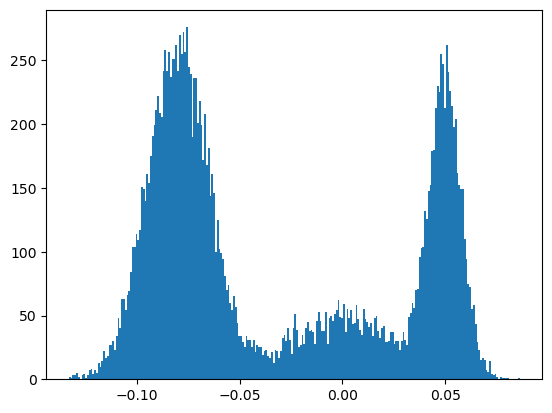

In [ ]:
plt.hist(obs[0, :], bins=250)

In [ ]:
from tqdm import tqdm
### Student's emission
err = []
HMM_list = []
N_cycles = 5

for i in tqdm(range(N_cycles)):
    
    pi = np.random.rand((3))
    pi = pi/np.sum(pi)
    
    params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05)],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05)],  # state 1
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05)]  # state 2
    ])
    
    emission = emission_model.Gaussian_Emission(3, obs, params)
    HMM = hmm.Hmm(3, emission, pi, A=None)
    
    err.append(HMM.Baum_Welch(obs, N_max=35, eps=1e-5))
    HMM_list.append(HMM)

  0%|          | 0/5 [00:00<?, ?it/s]

############################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration #1------------ -logL = [0.51906228]------------ $|\Delta$| = 100%
Iteration #2------------ -logL = [-1.66221989]------------ $|\Delta$| = 100%
Iteration #3------------ -logL = [-2.01455446]------------ $|\Delta$| = [21.19662836]%
Iteration #4------------ -logL = [-2.05281186]------------ $|\Delta$| = [1.89905023]%
Iteration #5------------ -logL = [-2.05512812]------------ $|\Delta$| = [0.11283334]%
Iteration #6------------ -logL = [-2.05795134]------------ $|\Delta$| = [0.13737428]%
Iteration #7------------ -logL = [-2.06359739]------------ $|\Delta$| = [0.27435294]%
Iteration #8------------ -logL = [-2.07159572]------------ $|\Delta$| = [0.3875919]%
Iteration #9------------ -logL = [-2.07813469]------------ $|\Delta$| = [0.31564877]%
Iteration #10------------ -logL = [-2.08164606]------------ $|\Delta$| 

 20%|██        | 1/5 [00:11<00:44, 11.04s/it]

Iteration #36------------ -logL = [-2.08617737]------------ $|\Delta$| = [0.01669355]%
Learning Finished
###############################################################################################################
############################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration #1------------ -logL = [-0.22194535]------------ $|\Delta$| = 100%
Iteration #2------------ -logL = [-1.6714455]------------ $|\Delta$| = 100%
Iteration #3------------ -logL = [-2.12884863]------------ $|\Delta$| = [27.36572211]%
Iteration #4------------ -logL = [-2.26087699]------------ $|\Delta$| = [6.20186728]%
Iteration #5------------ -logL = [-2.26268071]------------ $|\Delta$| = [0.07977964]%
Iteration #6------------ -logL = [-2.26315808]------------ $|\Delta$| = [0.0210976]%
Iteration #7------------ -logL = [-2.26345491]------------ $|\Delta$| = [0.01311541]%
Iteration #8------------ -

 40%|████      | 2/5 [00:16<00:22,  7.53s/it]

...

Iteration #20------------ -logL = [-2.56866307]------------ $|\Delta$| = [4.91190241e-05]%
Learning Finished
###############################################################################################################
############################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration #1------------ -logL = [-1.35866756]------------ $|\Delta$| = 100%
Iteration #2------------ -logL = [-2.03887721]------------ $|\Delta$| = 100%
Iteration #3------------ -logL = [-2.10572513]------------ $|\Delta$| = [3.27866366]%
Iteration #4------------ -logL = [-2.17650112]------------ $|\Delta$| = [3.3611218]%
Iteration #5------------ -logL = [-2.24306455]------------ $|\Delta$| = [3.05827701]%
Iteration #6------------ -logL = [-2.26266173]------------ $|\Delta$| = [0.87367867]%
Iteration #7------------ -logL = [-2.26422406]------------ $|\Delta$| = [0.06904818]%
Iteration #8----------

 80%|████████  | 4/5 [00:24<00:05,  5.23s/it]

Iteration #9------------ -logL = [-2.26431444]------------ $|\Delta$| = [0.00049064]%
Learning Finished
###############################################################################################################
############################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration #1------------ -logL = [-1.04895887]------------ $|\Delta$| = 100%
Iteration #2------------ -logL = [-1.47305745]------------ $|\Delta$| = 100%
Iteration #3------------ -logL = [-1.59998615]------------ $|\Delta$| = [8.6166835]%
Iteration #4------------ -logL = [-1.94462619]------------ $|\Delta$| = [21.54018943]%
Iteration #5------------ -logL = [-2.34003601]------------ $|\Delta$| = [20.33346171]%
Iteration #6------------ -logL = [-2.46171908]------------ $|\Delta$| = [5.20005094]%
Iteration #7------------ -logL = [-2.52080159]------------ $|\Delta$| = [2.40005111]%
Iteration #8------------ 

100%|██████████| 5/5 [00:28<00:00,  5.64s/it]

Iteration #11------------ -logL = [-2.56866269]------------ $|\Delta$| = [0.0004334]%
Learning Finished
###############################################################################################################


Text(0, 0.5, '- log-likelihood')

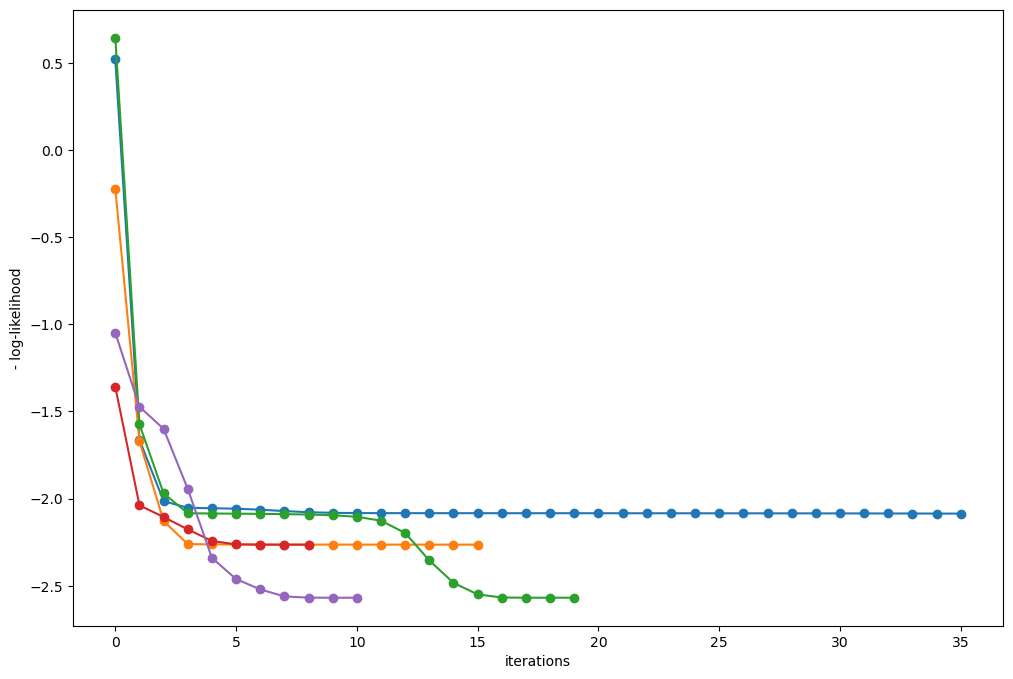

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for i in range(N_cycles):
    
    plt.plot(err[i], marker= 'o')


plt.xlabel('iterations')
plt.ylabel('- log-likelihood')

# Synthethic Student Data

In [2]:
# I generate a synthetic dataset 

def generate_hmm_data(T=2000, seed=42):
    
    rng = np.random.default_rng(seed)
    # True params: 3 regimes (bull, bear, volatile)
    mu    = [0.05,  -0.08,  0.00]
    sigma = [0.008,  0.015,  0.025]
    nu    = [30.0,    5.0,    3.0]   # bull≈Gaussian, volatile=fat tail
    A = np.array([[0.9, 0.08, 0.02],
                  [0.03, 0.95, 0.02],
                  [0.05, 0.05, 0.90]])
    
    states, obs = [], []
    s = 0
    for _ in range(T):
        states.append(s)
        # Student-t sample
        x = rng.standard_t(nu[s]) * sigma[s] + mu[s]
        obs.append(x)
        s = rng.choice(3, p=A[s])
    return np.array(obs), np.array(states)

In [3]:
obs, states = generate_hmm_data(T=40000)
obs=obs.reshape((1, obs.shape[0]))

(-0.2, 0.15)

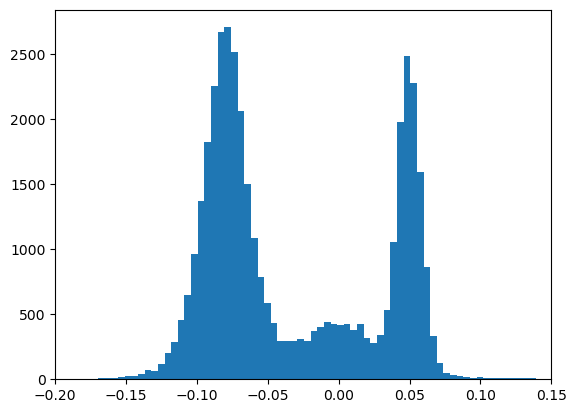

In [4]:
plt.hist(obs[0, :], bins=450)
plt.xlim(-0.2, 0.15)

In [5]:
from tqdm import tqdm
### Student's emission
err = []
HMM_list = []
N_cycles = 1

for i in tqdm(range(N_cycles)):
    
    pi = np.random.rand((3))
    pi = pi/np.sum(pi)
    
    student_params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0, 0.05), np.random.uniform(3.1, 40)],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), np.random.uniform(3.1, 40)],  # state 1
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), np.random.uniform(3.1, 40)]  # state 1
    ])
    
    emission = emission_model.Student_Emission(3, obs, student_params=student_params, count_max=60, tol_maximization=5e-2)
    HMM = hmm.Hmm(3, emission, pi, A=None)
    
    err.append(HMM.Baum_Welch(obs, N_max=35, eps=1e-5))
    HMM_list.append(HMM)



  0%|          | 0/1 [00:00<?, ?it/s]

############################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 


  0%|          | 0/1 [00:00<?, ?it/s]


ValueError: f(a) and f(b) must have different signs

IndexError: list index out of range

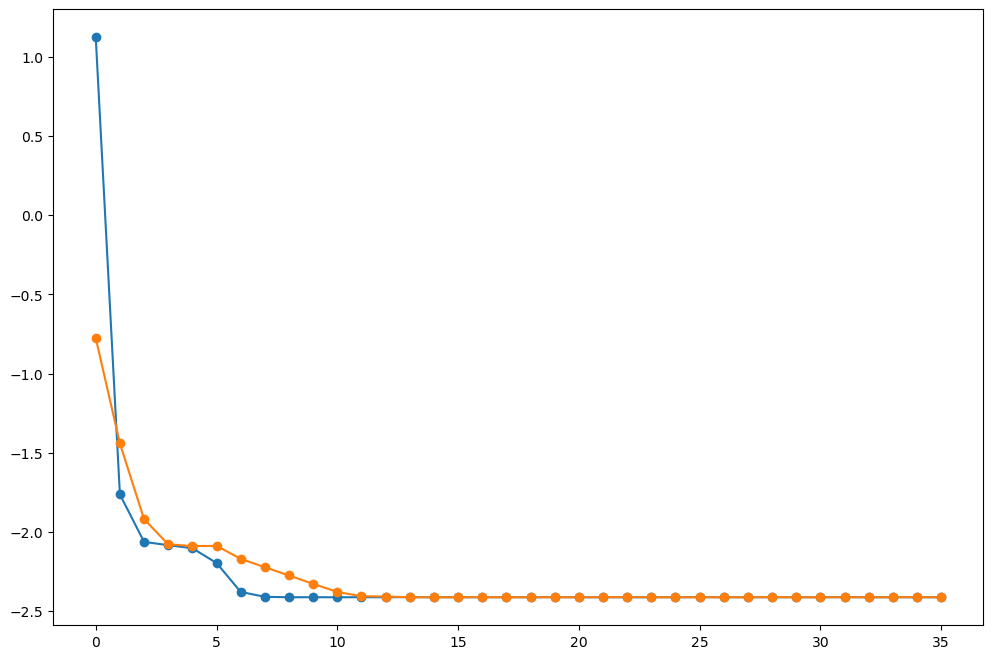

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for i in range(N_cycles):
    
    plt.plot(err[i], marker= 'o')


plt.xlabel('iterations')
plt.ylabel('- log-likelihood')

